# Aproximarea ariilor neregulate cu metoda Monte Carlo

## Idee:

- In majoritatea cazurilor, este dificil sa calculam aria unor forme neregulate, de exemplu formate prin suprapunerea aleatoare a mai multor poligoane si elipse.

- Cu metoda Monte Carlo, insa, aria unor astfel de figuri poate fi aproximata cu usurinta.

- Proiectul consta in 2 pasi:
    1. Generarea formelor aleatoare
    2. Aproximarea ariilor cu Monte Carlo

### Pasul 1: Generarea formelor aleatoare
Am folosit biblioteca `scikit-image` pentru a avea acces la functii ce genereaza poligoane si elipse.
Am definit o functie `get_img(x, y)` care retuneaza o matrice de marimea `x` pe `y` pixeli. Inauntrul acestei functii, sunt chemate `draw_polygon()` si `draw_ellipse()` care genereaza forme aleatoare si le insereaza in imagine.

Fiecare pixel alb il consideram ca facand parte din figura, iar fiecare pixel negru ca fiind in afara ei. Aria formei generate este, deci, numarul de pixeli albi din imagine (adica elementele matricii care au valoarea 1 si nu 0).

In [101]:
import numpy as np
import random
import matplotlib.pyplot as plt
from skimage.draw import (
    polygon,
    ellipse
)

In [102]:
def draw_polygon(img):
    max_x, max_y = img.shape
    nr_vertexes=random.randint(3, 10) # nr de varfuri
    poly = np.array([[random.randint(0, max_x), random.randint(0, max_y)] 
                     for _ in range(nr_vertexes)]) # lista cu coordonatele varfurilor
    rr, cc = polygon(poly[:, 0], poly[:, 1], img.shape)
    img[rr, cc] = 1

In [103]:
def draw_ellipse(img):
    max_x, max_y = img.shape
    max_radius = min(max_x, max_y) // 4
    min_radius = max_radius // 5
    radius_1 = random.randint(min_radius, max_radius)
    radius_2 = random.randint(min_radius, max_radius)
    c_coord_1 = random.randint(radius_1, max_x - radius_1) # coordonatele centrului
    c_coord_2 = random.randint(radius_2, max_y - radius_2)

    rr, cc = ellipse(c_coord_1, c_coord_2, radius_1, radius_2, img.shape, random.uniform(-np.pi, np.pi))
    img[rr, cc] = 1

In [104]:
def get_img(x, y):
    img = np.zeros((x, y))
    nr_shapes = random.randint(2, 8) # generam intre 2 si 8 elipse si poligoane
    shape_types = [random.randint(0, 1) for _ in range(nr_shapes)] # alegem aleatoriu intre cele 2 forme
    for val in shape_types:
        if val == 0:
            draw_polygon(img)
        else:
            draw_ellipse(img)
            
    return img

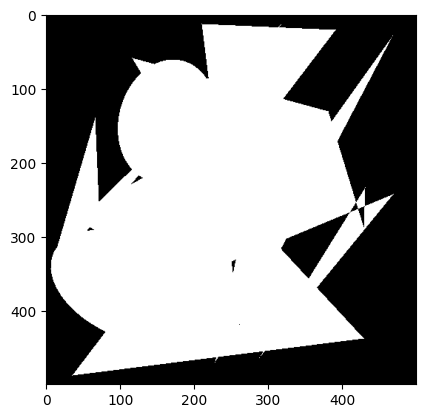

In [117]:
img = get_img(500, 500)
plt.imshow(img, cmap="gray")

### Pasul 2: Aplicarea metodei Monte Carlo
Generam `N` puncte pe spatiul definit `img`. Daca punctul corespunde unui pixel alb, inseamna ca face parte din forma generata si atunci va fi incrementat contorul `N_in`. 

Pentru a calcula aria aproximativa a formei, folosim urmatoarea formula:
$$
A_{est} = A_{img} * \frac{N_{in}}{N}
$$
unde
- $A_{est}$ - este aria estimata a figurii generate
- $A_{img}$ - este aria totala a spatiului (numarul de elemente in matricea `img`)
- $N_{in}$ - este numarul de puncte generate ce apartin figurii generate

In [106]:
def monte_carlo_area(img, N, verbose=False, visualize=False):
    x, y = img.shape
    xs = np.random.randint(0, x, N)
    ys = np.random.randint(0, y, N)
    points = img[xs, ys]
    N_in = np.count_nonzero(points) 
    A_est = x * y * (N_in / N) # aplicam formula de estimare a ariei
    A_real = np.sum(img)
    err_abs = abs(A_est - A_real)
    err_rel = round((err_abs / A_real)*100, 2)
    
    if verbose:
        print(f"N = {N}")
        print(f"Estimated area: {A_est} px")
        print(f"Real area: {A_real} px")
        print(f"Absolute error: {err_abs} px")
        print(f"Relative error: {err_rel}%")

    if visualize:
        plt.imshow(img, cmap='gray')
        plt.scatter(ys[points>0], xs[points>0], s=1, c='lime')
        plt.scatter(ys[points==0], xs[points==0], s=1, c='red')
        plt.title(f"N = {N} | {x}x{y} px")
        plt.show()

    return err_rel

N = 1000
Estimated area: 136000.0 px
Real area: 139063.0 px
Absolute error: 3063.0 px
Relative error: 2.2%


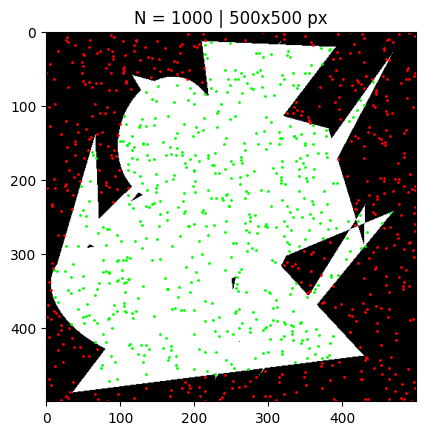

In [120]:
err = monte_carlo_area(img, N=1000, verbose=True, visualize=True)

N = 15000
Estimated area: 138983.3333333333 px
Real area: 139063.0 px
Absolute error: 79.66666666668607 px
Relative error: 0.06%


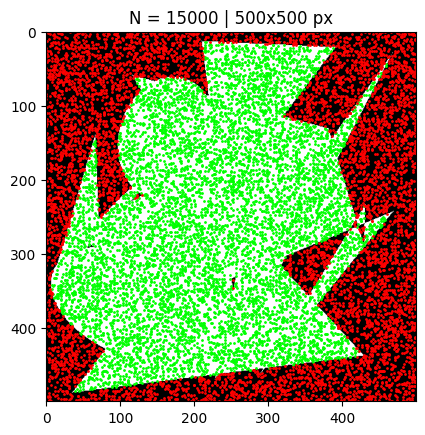

In [125]:
err = monte_carlo_area(img, N=15000, verbose=True, visualize=True)

N=50, Avg err=9.352%, std=7.344
N=100, Avg err=6.637%, std=4.782
N=500, Avg err=3.047%, std=2.246
N=1000, Avg err=2.071%, std=1.455
N=5000, Avg err=0.901%, std=0.667
N=10000, Avg err=0.692%, std=0.436
N=50000, Avg err=0.311%, std=0.237
N=100000, Avg err=0.232%, std=0.162
N=500000, Avg err=0.107%, std=0.080
N=1000000, Avg err=0.076%, std=0.055


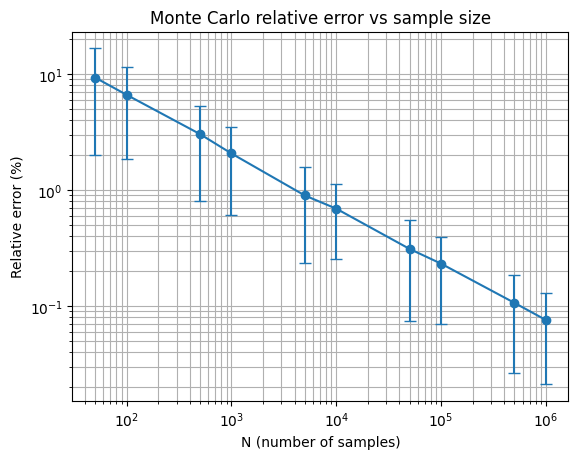

In [126]:
Ns = [50, 10**2, 5*10**2, 10**3, 5*10**3, 10**4, 5*10**4, 10**5, 5*10**5, 10**6]
err_avgs = []
err_stds = []

R = 100 # numarul de repetari pt fiecare N
for N in Ns:
    errs = [monte_carlo_area(img, N) for _ in range(R)]
    err_avgs.append(np.mean(errs))
    err_stds.append(np.std(errs))
    print(f"N={N}, Avg err={err_avgs[-1]:.3f}%, std={err_stds[-1]:.3f}")

plt.figure()
plt.errorbar(Ns, err_avgs, yerr=err_stds, fmt='o-', capsize=4)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("N (number of samples)")
plt.ylabel("Relative error (%)")
plt.title("Monte Carlo relative error vs sample size")
plt.grid(True, which='both')
plt.show()
